<br><br><center><h1 style="font-size:2em;color:#2467C0">Caso de estudio:  Reconocimiento de dígitos  </h1></center>
<br>



# 1. Configuración inicial

In [1]:
#!lscpu  # Información del procesador
#!free -h  # Memoria RAM disponible
#!nvidia-smi  # Si hay GPU, muestra detalles

In [2]:
# Librerias de ayuda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 2. Obtención y preparación de datos

In [3]:
# TensorFlow y tf.keras
import tensorflow as tf
from tensorflow import keras

mnist = keras.datasets.mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()


In [ ]:
#Tamaño de las muestras
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [5]:
#Definir las clases en una variable llamada class_names
# 'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
class_names = ['Camiseta/playera', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo',
               'Sandalia', 'Camisa', 'Tenis ', 'Bolsa de mano', 'Bota de tobillo']

# 3. Analisis explotario

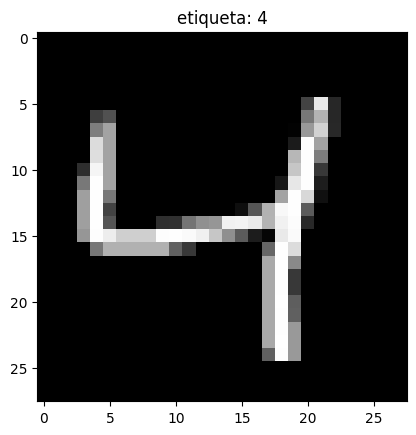

In [6]:
# Graficar al2un elemento
i=2
plt.imshow(train_images[i], cmap="gray")
plt.title('etiqueta: ' + str(train_labels[i]))
plt.show()

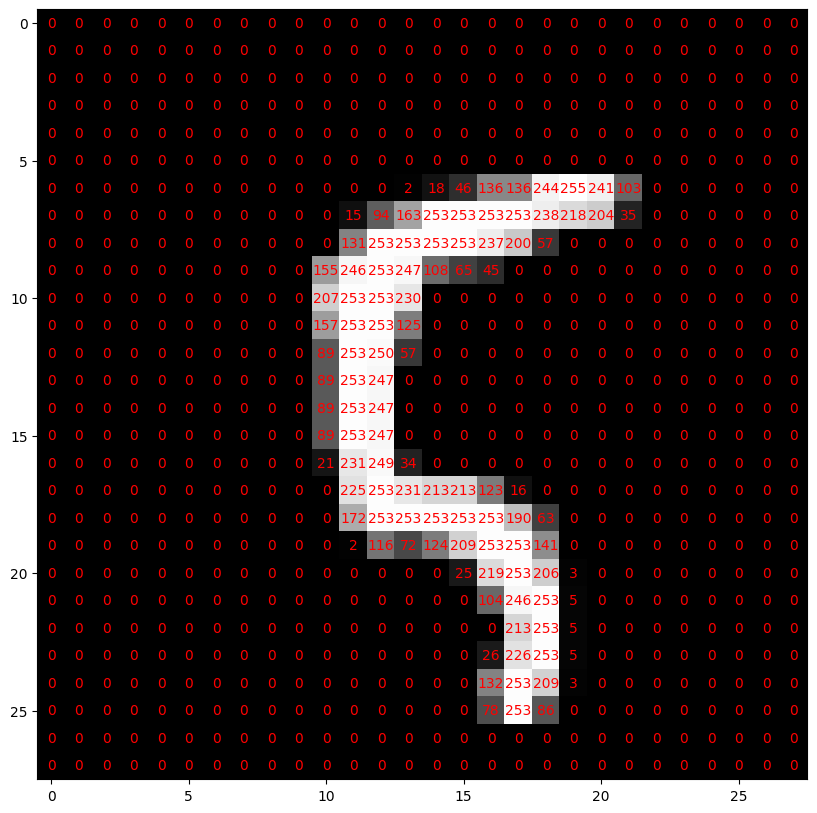

In [7]:
#Agregar los valores de los pixeles
i=100
plt.figure(figsize=(10,10))
plt.imshow(train_images[i], cmap="gray")
for (j,i),label in np.ndenumerate(train_images[i]):
    plt.text(i,j,label,ha='center',va='center',color='red')
plt.show()

## 3.1 Re-escalamiento de los pixeles

Es necesario re-escalar estos valores en un rango de 0 a 1 antes de alimentarlos al modelo de la red neuronal. Dividir los valores por 255. Es importante aplicarlo a ambos al de training  y al de testing.

In [8]:
# Dividir entre 255
train_images = train_images / 255
test_images = test_images / 255

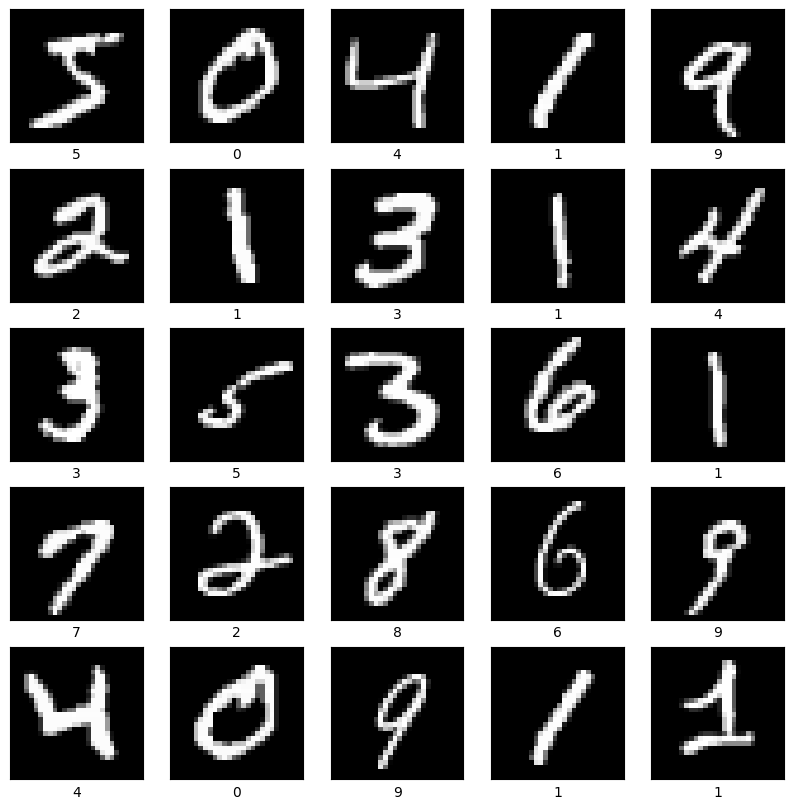

In [9]:
#Mostrar algunas imagenes
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap='gray')
    plt.xlabel(train_labels[i])
plt.show()

# 4. Definición del Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilarlo.

In [ ]:
#Mostrar el tamaño de las imagenes de entrenamiento y test
print(train_images.shape )
print(test_images.shape )

(60000, 28, 28)
(10000, 28, 28)


In [11]:
#Realizar el flatten
train_images_flatten = train_images.reshape(train_images.shape[0], train_images.shape[1]*train_images.shape[2])
test_images_flatten = test_images.reshape(test_images.shape[0], test_images.shape[1]*train_images.shape[2])

In [12]:
#Definir un modelo de 1 capa de 10 neuronas y una capa de salida
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(train_images_flatten.shape[1], )))
model.add(Dense(196, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 196)            │       153,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,118 (652.80 KB)

 Trainable params: 167,118 (652.80 KB)

 Non-trainable params: 0 (0.00 B)

# 5. Configuración del proceso de aprendizaje

In [13]:
#Compilar el modelo con las siguientes opciones optimizer='adam',   loss='sparse_categorical_crossentropy',  metrics=['accuracy']
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 6. Entrenamiento del modelo

In [14]:
#Realizar el entrenamiento
history = model.fit(train_images_flatten, train_labels, validation_split=0.2, epochs=30,batch_size=30)

Epoch 1/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8596 - loss: 0.4548 - val_accuracy: 0.9500 - val_loss: 0.1654
Epoch 2/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9285 - loss: 0.2432 - val_accuracy: 0.9592 - val_loss: 0.1336
Epoch 3/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9408 - loss: 0.2035 - val_accuracy: 0.9670 - val_loss: 0.1123
Epoch 4/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9492 - loss: 0.1693 - val_accuracy: 0.9711 - val_loss: 0.0991
Epoch 5/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9534 - loss: 0.1567 - val_accuracy: 0.9712 - val_loss: 0.1012
Epoch 6/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9573 - loss: 0.1430 - val_accuracy: 0.9728 - val_loss: 0.0947
Epoch 7/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9586 - loss: 0.1383 - val_accuracy: 0.9712 - val_loss: 0.0962
Epoch 8/30
1600/1600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9600 - loss: 0.1315 - 

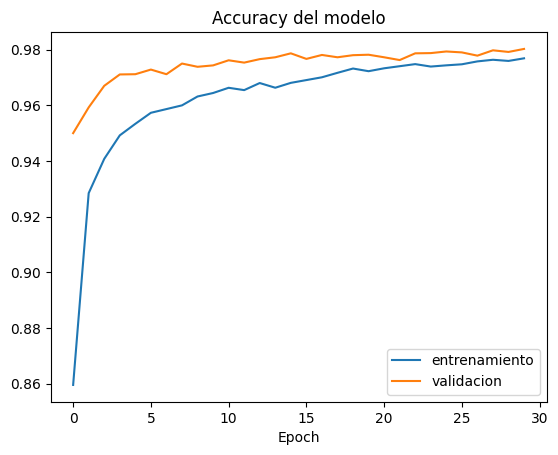

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy del modelo')
plt.xlabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['entrenamiento','validacion'])
plt.show()

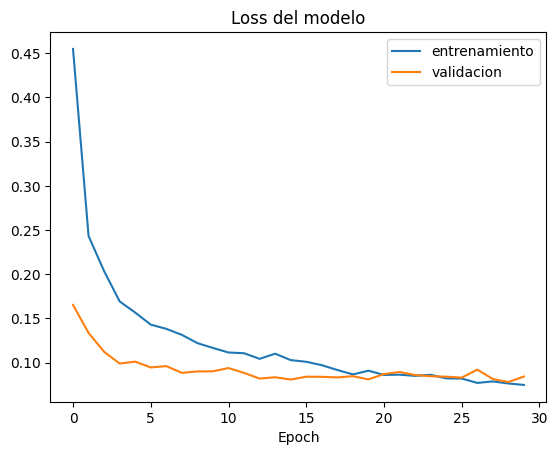

In [16]:
# Historial de loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss del modelo')
plt.xlabel('Loss')
plt.xlabel('Epoch')
plt.legend(['entrenamiento','validacion'])
plt.show()

# 7. Evaluación del modelo

In [17]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(img, cmap=plt.cm.binary)
  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'
  plt.xlabel("{} {:2.0f}% ({})".format(predicted_label,
                                100*np.max(predictions_array),
                                true_label),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

In [18]:
#Evaluación del modelo
model.evaluate(test_images_flatten,  test_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9785 - loss: 0.0809


[0.0808507651090622, 0.9785000085830688]

In [19]:
predictions_images = model.predict(test_images_flatten)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


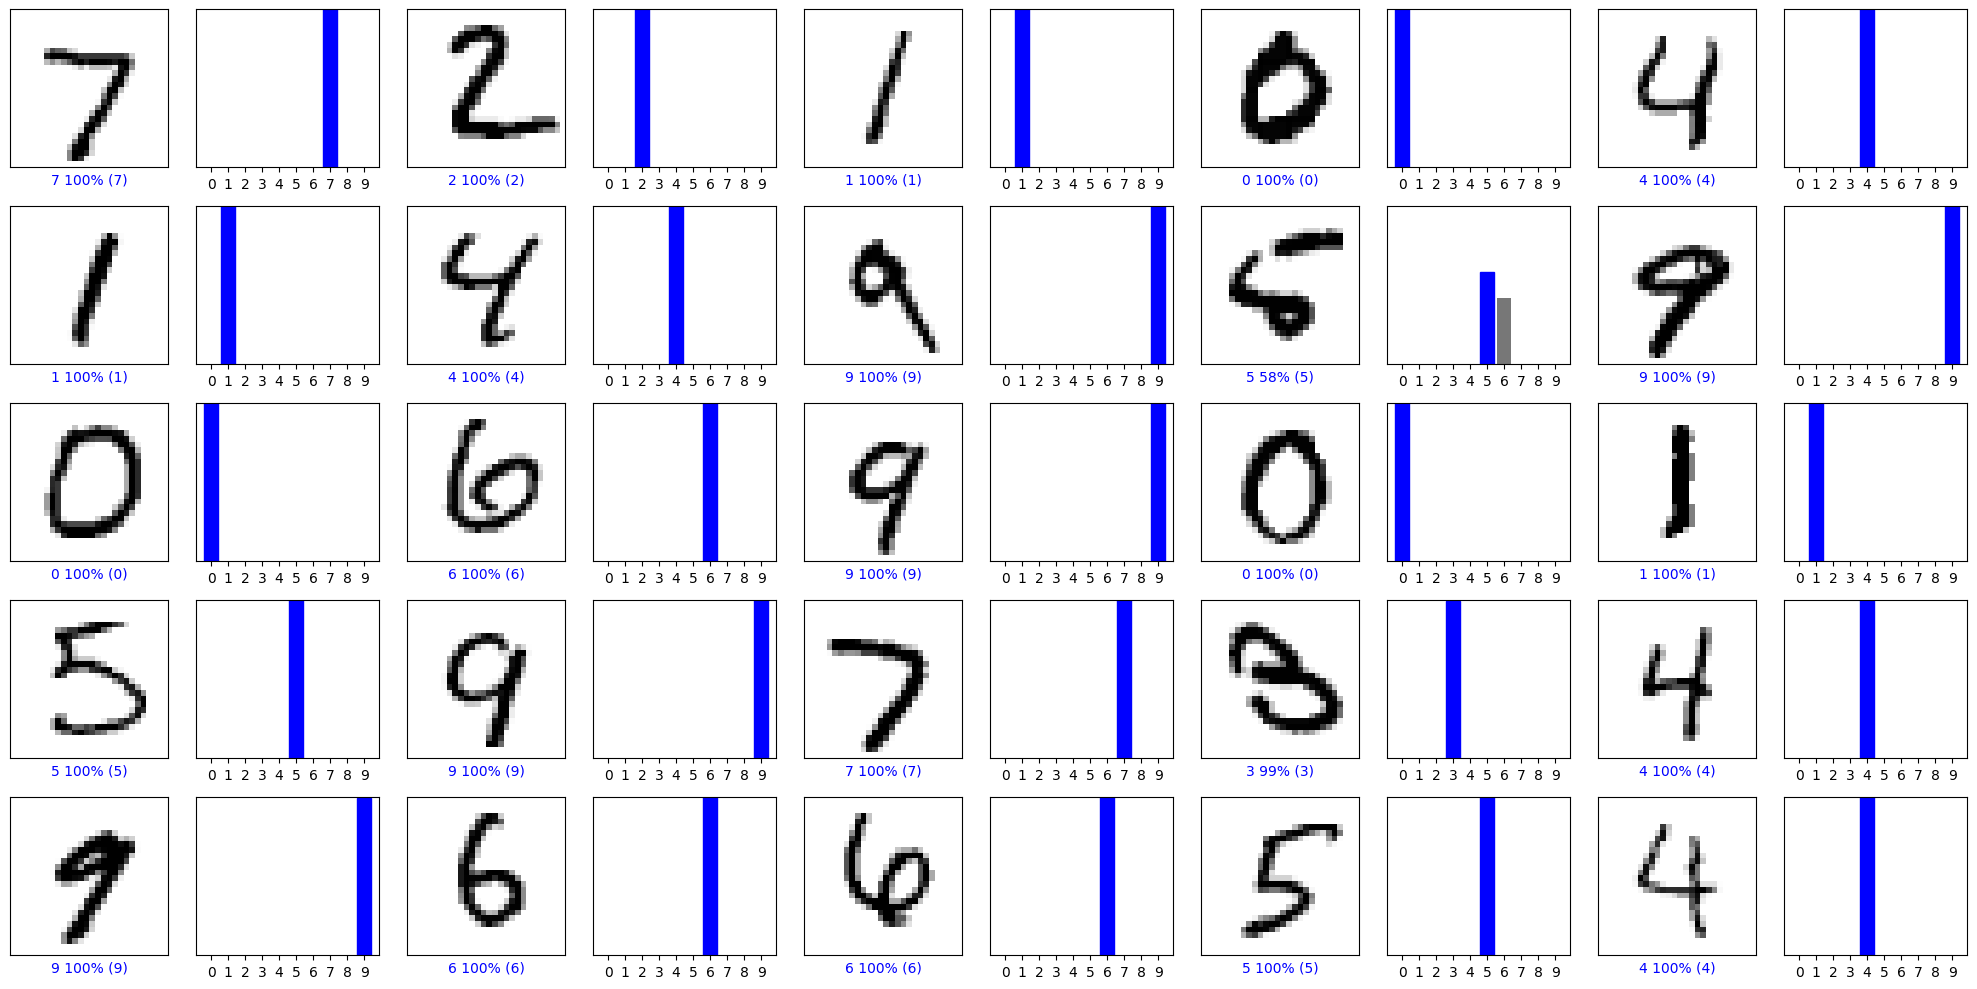

In [20]:
num_rows = 5
num_cols = 5
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
  plt.subplot(num_rows, 2*num_cols, 2*i+1)
  plot_image(i, predictions_images[i], test_labels, test_images)
  plt.subplot(num_rows, 2*num_cols, 2*i+2)
  plot_value_array(i, predictions_images[i], test_labels)
plt.tight_layout()
plt.show()

## Guardar el modelo completo (arquitectura + pesos)


In [27]:
#Guardar el modelo con el nombre model_fashion.keras
#modelo.save("model_fashion_oct2025_sinDropOut.keras")
model.save('modelo/model_mnist_Carlos_Chavarria.keras')

In [22]:
#!ls -lth "DireccionLOCAL"